# 02 — Treino da CNN-A (Baseline)

Arquitetura simples (3 blocos Conv+Pool), **sem regularização e sem aumento de dados**. Objetivo: estabelecer o piso de desempenho e evidenciar o overfitting que a CNN-B vai atacar.

> Recomendado rodar no **Google Colab com GPU** (Runtime → Change runtime type → T4 GPU). Treino ~5 min.

In [1]:
# >>> NO GOOGLE COLAB: rode ESTA célula primeiro (em ambiente local, pule) <<<
# Clona o repositório. NÃO instalamos requirements.txt no Colab: ele já traz
# TensorFlow, Keras, numpy, pandas, scikit-learn, matplotlib, seaborn e
# tensorflow-datasets em versões compatíveis entre si. Reinstalar versões
# fixas rebaixa o ml_dtypes/numpy e quebra o JAX do Colab.
!git clone https://github.com/luanmacea/gs-cnn-eurosat.git
%cd gs-cnn-eurosat

Cloning into 'gs-cnn-eurosat'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 55 (delta 25), reused 37 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 40.31 KiB | 8.06 MiB/s, done.
Resolving deltas: 100% (25/25), done.
/content/gs-cnn-eurosat


In [2]:
import sys, os
# Resolve a raiz do projeto de forma robusta (local OU Colab, com ou sem
# restart de runtime). Procura uma pasta que contenha 'src/'.
candidatos = [os.getcwd(), os.path.dirname(os.getcwd()), '/content/gs-cnn-eurosat']
ROOT = next((p for p in candidatos if os.path.isdir(os.path.join(p, 'src'))), os.getcwd())
os.chdir(ROOT)  # paths relativos (models/, reports/) consistentes
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
print('Project root:', ROOT)

Project root: /content/gs-cnn-eurosat


In [3]:
from src.data_loader import load_raw_data, make_splits, make_tf_datasets, CLASS_NAMES
from src.models import build_cnn_a
from src.train import compile_and_train, save_history
from src.evaluate import plot_training_curves

## Dados

In [4]:
images, labels = load_raw_data()
splits = make_splits(images, labels, seed=42)
train_ds, val_ds, test_ds = make_tf_datasets(splits, batch_size=64)

Baixando EuroSAT RGB de: https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1
  falhou (HTTPError: HTTP Error 403: Forbidden)
Baixando EuroSAT RGB de: https://zenodo.org/record/7711810/files/EuroSAT_RGB.zip?download=1
  falhou (HTTPError: HTTP Error 403: Forbidden)
Baixando EuroSAT RGB de: https://madm.dfki.de/files/sentinel/EuroSAT.zip
  falhou (URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)>)
Fonte indisponivel -> _load_from_zip: URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)>
Baixando EuroSAT RGB via Hugging Face (blanchon/EuroSAT_RGB)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/3.38k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/105M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/34.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16200 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5400 [00:00<?, ? examples/s]

Dataset carregado: 16200 imagens.


## Arquitetura

In [5]:
model_a = build_cnn_a()
model_a.summary()

Model: "CNN_A_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,490 (2.61 MB)

 Trainable params: 684,490 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

Note a camada `Flatten` seguida de `Dense(128)`: é responsável pela maior parte dos parâmetros da rede e, sem regularização, é onde o overfitting se instala.

## Treino
`EarlyStopping` (patience=5) monitora a `val_loss` e restaura os melhores pesos; `ModelCheckpoint` salva o melhor modelo por `val_accuracy`.

In [6]:
history_a = compile_and_train(
    model_a, train_ds, val_ds,
    epochs=30, lr=1e-3,
    checkpoint_path='models/cnn_a_best.keras',
    patience=5, use_reduce_lr=False,
)
save_history(history_a, 'reports/cnn_a_history.json')

Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.4203 - loss: 1.4651 - val_accuracy: 0.4782 - val_loss: 1.3768
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6155 - loss: 1.0326 - val_accuracy: 0.6469 - val_loss: 0.9531
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6897 - loss: 0.8562 - val_accuracy: 0.6835 - val_loss: 0.8816
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7240 - loss: 0.7617 - val_accuracy: 0.7346 - val_loss: 0.7449
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7580 - loss: 0.6659 - val_accuracy: 0.7235 - val_loss: 0.7647
Epoch 6/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7737 - loss: 0.6173 - val_accuracy: 0.6819 - val_loss: 0.8790
Epoch 7/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7883 - loss: 0.5849 - val_accuracy: 0.7770 - val_loss: 0.6097
Epoch 8/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8071 - loss: 0.5315 - val_accura

## Curvas de aprendizado

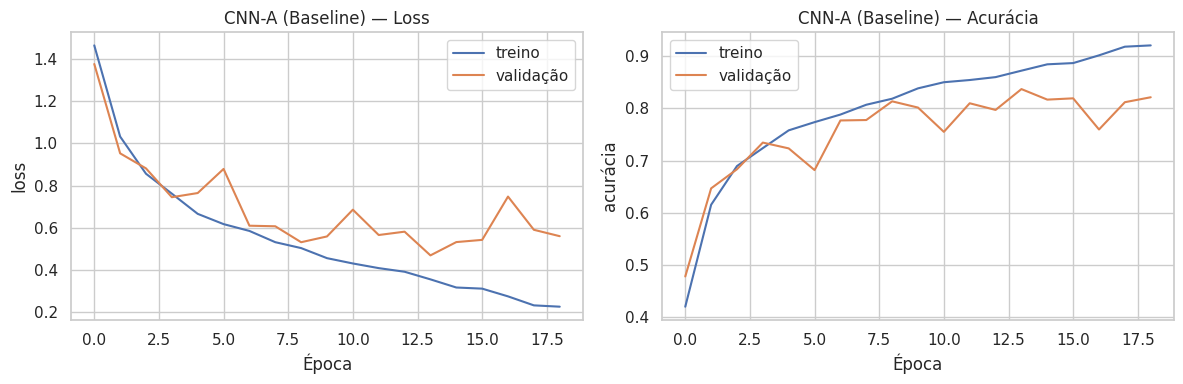

In [7]:
plot_training_curves(history_a.history, title='CNN-A (Baseline)',
                     save_path='reports/figures/cnn_a_curves.png')

## Avaliação no conjunto de teste

In [8]:
test_loss, test_acc = model_a.evaluate(test_ds, verbose=0)
print(f'CNN-A — acurácia no teste: {test_acc:.4f} | loss: {test_loss:.4f}')

CNN-A — acurácia no teste: 0.8214 | loss: 0.5158


**Leitura esperada.** A acurácia de treino tende a subir bem acima da de validação, e a `val_loss` para de cair (ou volta a subir) enquanto a `train_loss` continua caindo — a assinatura clássica de overfitting. Anote o valor de teste para comparar com a CNN-B.

*(Preencha os números reais após rodar.)*